#### coleta

In [195]:
#coleta dos dados
!unzip /content/saude.zip #file renamed manually

#imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. CARREGAMENTO E CONFIGURAÇÃO ---
df = pd.read_csv('/content/2 - Saude/dataset_saude_brasil.csv')
df.head()

#df0
df0 = df.copy()

Archive:  /content/saude.zip
replace 2 - Saude/dataset_saude_brasil.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: 2 - Saude/dataset_saude_brasil.csv  
  inflating: 2 - Saude/saude BR.txt  


#### Preparo inicial

In [ ]:
#shape
print(df.shape) #shape 20000 linhas e 17 colunas, 16 variáveis preditoras 1 predita

#limpeza inicial
print(df.duplicated().sum()) #sem dados duplicados

#dados nulos
print(df.isnull().sum())

#varisveis numericas que tem valores nulos
print(df.shape)
print(0.8*df.shape[0])
print(0.7*df.shape[0])

from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, test_size=0.2)
print(df_train.shape)
print(df_test.shape)



(20000, 17)
0
ID                               0
Idade                          349
Sexo                             0
IMC                            350
Passos_Diarios                 199
Horas_Sono                       0
Agua_Litros                      0
Calorias                       200
Fumante                          0
Alcool                           0
Horas_Trabalho                   0
Frequencia_Cardiaca_Repouso      0
Pressao_Sistolica                0
Pressao_Diastolica               0
Colesterol                     199
Historico_Familiar               0
Risco_Doenca                     0
dtype: int64


#### testes imputação ausentes

In [ ]:
df_com_nulos = df_train[['Idade','IMC','Passos_Diarios','Calorias','Colesterol']].copy()
1 - (df_train[['Idade','IMC','Passos_Diarios','Calorias','Colesterol']].isnull().sum()/df_train.shape[0])


,0
Idade,0.982688
IMC,0.981500
Passos_Diarios,0.990000
Calorias,0.989875
Colesterol,0.990437


In [ ]:
#taxa de completude alta --> colunas mantidas
df_com_nulos.info()


<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 11721 to 8796
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Idade           15723 non-null  float64
 1   IMC             15704 non-null  float64
 2   Passos_Diarios  15840 non-null  object 
 3   Calorias        15838 non-null  object 
 4   Colesterol      15847 non-null  object 
dtypes: float64(2), object(3)
memory usage: 750.0+ KB


In [ ]:
import pandas as pd
df_com_nulos['Passos_Diarios'] = pd.to_numeric(df_com_nulos['Passos_Diarios'], errors='coerce')
df_com_nulos['Calorias'] = pd.to_numeric(df_com_nulos['Calorias'], errors='coerce')
df_com_nulos['Colesterol'] = pd.to_numeric(df_com_nulos['Colesterol'], errors='coerce')
df_com_nulos.info()


<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 11721 to 8796
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Idade           15723 non-null  float64
 1   IMC             15704 non-null  float64
 2   Passos_Diarios  15720 non-null  float64
 3   Calorias        15716 non-null  float64
 4   Colesterol      15729 non-null  float64
dtypes: float64(5)
memory usage: 750.0 KB


In [209]:
df_com_nulos.describe()

,Idade,IMC,Passos_Diarios,Calorias,Colesterol
count,15723.000000,15704.000000,15720.000000,15716.000000,15729.000000
mean,53.487184,25.008144,10538.669593,3302.483265,212.709962
std,20.722508,4.995887,5460.700316,2015.875433,59.037216
min,18.000000,5.200000,1000.000000,1200.000000,120.000000
25%,35.000000,21.600000,5851.500000,2162.000000,165.000000
50%,53.000000,25.000000,10536.500000,3140.000000,211.000000
75%,71.000000,28.300000,15237.500000,4104.250000,257.000000
max,89.000000,45.500000,19999.000000,24970.000000,598.000000


In [210]:
df_com_nulos['Idade2'] = df_com_nulos['Idade'].fillna(df_com_nulos['Idade'].mean())
df_com_nulos['IMC2'] = df_com_nulos['IMC'].fillna(df_com_nulos['IMC'].mean())
df_com_nulos['Passos_Diarios2'] = df_com_nulos['Passos_Diarios'].fillna(df_com_nulos['Passos_Diarios'].mean())
df_com_nulos['Calorias2'] = df_com_nulos['Calorias'].fillna(df_com_nulos['Calorias'].mean())
df_com_nulos['Colesterol2'] = df_com_nulos['Colesterol'].fillna(df_com_nulos['Colesterol'].mean())

df_com_nulos['Idade3'] = df_com_nulos['Idade'].fillna(df_com_nulos['Idade'].median())
df_com_nulos['IMC3'] = df_com_nulos['IMC'].fillna(df_com_nulos['IMC'].median())
df_com_nulos['Passos_Diarios3'] = df_com_nulos['Passos_Diarios'].fillna(df_com_nulos['Passos_Diarios'].median())
df_com_nulos['Calorias3'] = df_com_nulos['Calorias'].fillna(df_com_nulos['Calorias'].median())
df_com_nulos['Colesterol3'] = df_com_nulos['Colesterol'].fillna(df_com_nulos['Colesterol'].median())

df_com_nulos['Idade4'] = df_com_nulos['Idade'].fillna(df_com_nulos['Idade'].ffill())
df_com_nulos['IMC4'] = df_com_nulos['IMC'].fillna(df_com_nulos['IMC'].ffill())
df_com_nulos['Passos_Diarios4'] = df_com_nulos['Passos_Diarios'].fillna(df_com_nulos['Passos_Diarios'].ffill())
df_com_nulos['Calorias4'] = df_com_nulos['Calorias'].fillna(df_com_nulos['Calorias'].ffill())
df_com_nulos['Colesterol4'] = df_com_nulos['Colesterol'].fillna(df_com_nulos['Colesterol'].ffill())

df_com_nulos['Idade5'] = df_com_nulos['Idade'].fillna(df_com_nulos['Idade'].bfill())
df_com_nulos['IMC5'] = df_com_nulos['IMC'].fillna(df_com_nulos['IMC'].bfill())
df_com_nulos['Passos_Diarios5'] = df_com_nulos['Passos_Diarios'].fillna(df_com_nulos['Passos_Diarios'].bfill())
df_com_nulos['Calorias5'] = df_com_nulos['Calorias'].fillna(df_com_nulos['Calorias'].bfill())
df_com_nulos['Colesterol5'] = df_com_nulos['Colesterol'].fillna(df_com_nulos['Colesterol'].bfill())


In [211]:
df_com_nulos[['Idade','Idade2','Idade3','Idade4','Idade5']].describe()

,Idade,Idade2,Idade3,Idade4,Idade5
count,15723.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,53.487184,53.487184,53.478750,53.461000,53.474562
std,20.722508,20.542335,20.542433,20.721232,20.719401
min,18.000000,18.000000,18.000000,18.000000,18.000000
25%,35.000000,36.000000,36.000000,35.000000,35.000000
50%,53.000000,53.487184,53.000000,53.000000,53.000000
75%,71.000000,71.000000,71.000000,71.000000,71.000000
max,89.000000,89.000000,89.000000,89.000000,89.000000


In [212]:
df_com_nulos[['IMC','IMC2','IMC3','IMC4', 'IMC5']].describe()

,IMC,IMC2,IMC3,IMC4,IMC5
count,15704.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,25.008144,25.008144,25.007994,25.012369,25.005163
std,4.995887,4.949457,4.949457,4.998722,4.998349
min,5.200000,5.200000,5.200000,5.200000,5.200000
25%,21.600000,21.700000,21.700000,21.700000,21.600000
50%,25.000000,25.008144,25.000000,25.000000,25.000000
75%,28.300000,28.300000,28.300000,28.400000,28.300000
max,45.500000,45.500000,45.500000,45.500000,45.500000


In [214]:
df_com_nulos[['Calorias','Calorias2','Calorias3','Calorias4','Calorias5']].describe()

,Calorias,Calorias2,Calorias3,Calorias4,Calorias5
count,15716.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,3302.483265,3302.483265,3299.599187,3305.852750,3300.754188
std,2015.875433,1997.903307,1998.018506,2025.315234,2015.067943
min,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
25%,2162.000000,2180.000000,2180.000000,2162.000000,2160.000000
50%,3140.000000,3172.000000,3140.000000,3142.000000,3139.000000
75%,4104.250000,4090.250000,4090.250000,4108.000000,4103.000000
max,24970.000000,24970.000000,24970.000000,24970.000000,24970.000000


In [215]:
df_com_nulos[['Passos_Diarios','Passos_Diarios2','Passos_Diarios3','Passos_Diarios4', 'Passos_Diarios5']].describe()

,Passos_Diarios,Passos_Diarios2,Passos_Diarios3,Passos_Diarios4,Passos_Diarios5
count,15720.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,10538.669593,10538.669593,10538.631625,10530.365813,10534.977063
std,5460.700316,5412.705284,5412.705291,5461.570299,5460.333093
min,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
25%,5851.500000,5936.000000,5936.000000,5837.000000,5845.000000
50%,10536.500000,10538.669593,10536.500000,10527.000000,10528.000000
75%,15237.500000,15156.250000,15156.250000,15235.000000,15233.000000
max,19999.000000,19999.000000,19999.000000,19999.000000,19999.000000


In [216]:
df_com_nulos[['Colesterol','Colesterol2','Colesterol3','Colesterol4', 'Colesterol5']].describe()

,Colesterol,Colesterol2,Colesterol3,Colesterol4,Colesterol5
count,15729.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,212.709962,212.709962,212.681000,212.828812,212.679188
std,59.037216,58.535078,58.535494,58.973436,58.994873
min,120.000000,120.000000,120.000000,120.000000,120.000000
25%,165.000000,166.000000,166.000000,165.000000,165.000000
50%,211.000000,212.000000,211.000000,211.000000,211.000000
75%,257.000000,256.000000,256.000000,257.000000,257.000000
max,598.000000,598.000000,598.000000,598.000000,598.000000


In [217]:
#valores discrepantes

def contar_outliers_iqr_series(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    li = Q1 - 1.5 * IQR
    ls = Q3 + 1.5 * IQR
    return ((serie < li) | (serie > ls)).sum()


def contar_outliers_dataframe(df, colunas):
    return {col: contar_outliers_iqr_series(df[col]) for col in colunas}

In [218]:
print("Idade")
print(contar_outliers_dataframe(df_com_nulos, ['Idade','Idade2','Idade3','Idade4','Idade5']))
print("IMC")
print(contar_outliers_dataframe(df_com_nulos, ['IMC','IMC2','IMC3','IMC4', 'IMC5']))
print("Colesterol")
print(contar_outliers_dataframe(df_com_nulos, ['Colesterol','Colesterol2','Colesterol3','Colesterol4', 'Colesterol5']))
print("Calorias")
print(contar_outliers_dataframe(df_com_nulos, ['Calorias','Calorias2','Calorias3','Calorias4','Calorias5']))
print(("Passos_Diarios"))
print(contar_outliers_dataframe(df_com_nulos, ['Passos_Diarios','Passos_Diarios2','Passos_Diarios3','Passos_Diarios4', 'Passos_Diarios5']))

Idade
{'Idade': np.int64(0), 'Idade2': np.int64(0), 'Idade3': np.int64(0), 'Idade4': np.int64(0), 'Idade5': np.int64(0)}
IMC
{'IMC': np.int64(108), 'IMC2': np.int64(119), 'IMC3': np.int64(119), 'IMC4': np.int64(106), 'IMC5': np.int64(109)}
Colesterol
{'Colesterol': np.int64(136), 'Colesterol2': np.int64(137), 'Colesterol3': np.int64(137), 'Colesterol4': np.int64(139), 'Colesterol5': np.int64(138)}
Calorias
{'Calorias': np.int64(239), 'Calorias2': np.int64(239), 'Calorias3': np.int64(239), 'Calorias4': np.int64(248), 'Calorias5': np.int64(241)}
Passos_Diarios
{'Passos_Diarios': np.int64(0), 'Passos_Diarios2': np.int64(0), 'Passos_Diarios3': np.int64(0), 'Passos_Diarios4': np.int64(0), 'Passos_Diarios5': np.int64(0)}


#### Preenchimento auasentes

In [219]:
#técnica escolhida menos outliers: media
df_train['Passos_Diarios'] = pd.to_numeric(df_train['Passos_Diarios'], errors='coerce')
df_train['Calorias'] = pd.to_numeric(df_train['Calorias'], errors='coerce')
df_train['Colesterol'] = pd.to_numeric(df_train['Colesterol'], errors='coerce')


df_train['Idade'] = df_train['Idade'].fillna(df_train['Idade'].mean())
df_train['IMC'] = df_train['IMC'].fillna(df_train['IMC'].mean())
df_train['Passos_Diarios'] = df_train['Passos_Diarios'].fillna(df_train['Passos_Diarios'].mean())
df_train['Calorias'] = df_train['Calorias'].fillna(df_train['Calorias'].mean())
df_train['Colesterol'] = df_train['Colesterol'].fillna(df_train['Colesterol'].mean())


In [220]:
df_train.isnull().sum()

,0
ID,0
Idade,0
Sexo,0
IMC,0
Passos_Diarios,0
Horas_Sono,0
Agua_Litros,0
Calorias,0
Fumante,0
Alcool,0


#### Seleção coluna

In [221]:
#remoção coluna ID
df_train = df_train.drop(columns=['ID'])


#### Estudo categorias

In [222]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 11721 to 8796
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Idade                        16000 non-null  float64
 1   Sexo                         16000 non-null  object 
 2   IMC                          16000 non-null  float64
 3   Passos_Diarios               16000 non-null  float64
 4   Horas_Sono                   16000 non-null  float64
 5   Agua_Litros                  16000 non-null  float64
 6   Calorias                     16000 non-null  float64
 7   Fumante                      16000 non-null  object 
 8   Alcool                       16000 non-null  object 
 9   Horas_Trabalho               16000 non-null  int64  
 10  Frequencia_Cardiaca_Repouso  16000 non-null  int64  
 11  Pressao_Sistolica            16000 non-null  int64  
 12  Pressao_Diastolica           16000 non-null  int64  
 13  Colesterol        

In [223]:
df_train.head(1)

,Idade,Sexo,IMC,Passos_Diarios,Horas_Sono,Agua_Litros,Calorias,Fumante,Alcool,Horas_Trabalho,Frequencia_Cardiaca_Repouso,Pressao_Sistolica,Pressao_Diastolica,Colesterol,Historico_Familiar,Risco_Doenca
11721,55.0,Feminino,23.8,11375.0,6.8,1.6,2894.0,Não,Baixo,10,67,93,117,288.0,Não,Baixo


In [224]:
df_train.columns

Index(['Idade', 'Sexo', 'IMC', 'Passos_Diarios', 'Horas_Sono', 'Agua_Litros',
       'Calorias', 'Fumante', 'Alcool', 'Horas_Trabalho',
       'Frequencia_Cardiaca_Repouso', 'Pressao_Sistolica',
       'Pressao_Diastolica', 'Colesterol', 'Historico_Familiar',
       'Risco_Doenca'],
      dtype='object')

In [225]:
features_num = ['Idade', 'IMC', 'Passos_Diarios', 'Horas_Sono', 'Agua_Litros',
       'Calorias', 'Horas_Trabalho',
       'Frequencia_Cardiaca_Repouso', 'Pressao_Sistolica',
       'Pressao_Diastolica', 'Colesterol']
features_cat = ['Sexo', 'Fumante', 'Alcool', 'Historico_Familiar']
label = 'Risco_Doenca'

In [226]:
print(f"{len(features_num)} Features numéricas: {features_num}")
print(f"{len(features_cat)} Features categóricas: {features_cat}")
print(f"Label: {label}")

11 Features numéricas: ['Idade', 'IMC', 'Passos_Diarios', 'Horas_Sono', 'Agua_Litros', 'Calorias', 'Horas_Trabalho', 'Frequencia_Cardiaca_Repouso', 'Pressao_Sistolica', 'Pressao_Diastolica', 'Colesterol']
4 Features categóricas: ['Sexo', 'Fumante', 'Alcool', 'Historico_Familiar']
Label: Risco_Doenca


In [227]:
df_train[features_cat]

,Sexo,Fumante,Alcool,Historico_Familiar
11721,Feminino,Não,Baixo,Não
6924,Feminino,Não,Baixo,Sim
11252,Feminino,Sim,Baixo,Não
16946,Feminino,Sim,Moderado,Sim
1338,Feminino,Não,Baixo,Não
...,...,...,...,...
6669,Masculino,Não,Moderado,Sim
5573,Feminino,Não,Baixo,Não
10542,Feminino,Não,Moderado,Não
15408,Masculino,Não,Baixo,Não


In [228]:
df_cat_features_cat = df_train[features_cat].value_counts()

In [229]:
df_cat_features_cat

Sexo       Fumante  Alcool    Historico_Familiar
Masculino  Não      Baixo     Não                   2632
Feminino   Não      Baixo     Não                   2575
Masculino  Não      Moderado  Não                   1433
Feminino   Não      Moderado  Não                   1406
Masculino  Não      Baixo     Sim                   1187
Feminino   Não      Baixo     Sim                   1067
           Sim      Baixo     Não                    687
Masculino  Sim      Baixo     Não                    659
Feminino   Não      Moderado  Sim                    617
Masculino  Não      Moderado  Sim                    590
                    Alto      Não                    482
Feminino   Não      Alto      Não                    446
Masculino  Sim      Moderado  Não                    348
Feminino   Sim      Moderado  Não                    329
Masculino  Sim      Baixo     Sim                    290
Feminino   Sim      Baixo     Sim                    261
           Não      Alto      Sim                    204
Masculino  Não      Alto      Sim                    173
           Sim      Moderado  Sim                    151
Feminino   Sim      Moderado  Sim                    142
Masculino  Sim      Alto      Não                    110
Feminino   Sim      Alto      Não                    110
                              Sim                     53
Masculino  Sim      Alto      Sim                     48
Name: count, dtype: int64

In [230]:
df_train[features_num]

,Idade,IMC,Passos_Diarios,Horas_Sono,Agua_Litros,Calorias,Horas_Trabalho,Frequencia_Cardiaca_Repouso,Pressao_Sistolica,Pressao_Diastolica,Colesterol
11721,55.0,23.8,11375.000000,6.8,1.6,2894.0,10,67,93,117,288.0
6924,31.0,32.5,10538.669593,7.6,3.4,1644.0,11,53,169,72,144.0
11252,36.0,19.5,18245.000000,4.4,1.7,3984.0,7,66,117,102,178.0
16946,30.0,22.2,1090.000000,8.5,2.3,3279.0,11,97,131,101,158.0
1338,88.0,22.3,19744.000000,7.1,1.8,4302.0,9,58,141,78,194.0
...,...,...,...,...,...,...,...,...,...,...,...
6669,43.0,23.8,9718.000000,6.8,2.0,3827.0,5,51,118,76,226.0
5573,21.0,22.6,9522.000000,7.7,1.8,4660.0,9,90,98,68,212.0
10542,20.0,30.3,9221.000000,8.1,2.4,3307.0,12,94,164,60,167.0
15408,89.0,23.6,17745.000000,6.9,2.1,19920.0,10,98,129,90,598.0


In [231]:
df_cat_features_num = df_train[features_num].value_counts()

In [232]:
df_cat_features_num

Idade  IMC   Passos_Diarios  Horas_Sono  Agua_Litros  Calorias  Horas_Trabalho  Frequencia_Cardiaca_Repouso  Pressao_Sistolica  Pressao_Diastolica  Colesterol
89.0   32.2  17262.0         6.0         1.1          2530.0    10              69                           105                100                 126.0         1
       32.1  11172.0         6.7         1.6          3232.0    12              88                           109                100                 243.0         1
             11008.0         7.1         0.4          4626.0    13              61                           176                96                  265.0         1
       31.9  2220.0          5.4         2.2          3285.0    10              82                           129                67                  167.0         1
       31.7  15623.0         5.4         2.3          2682.0    6               55                           96                 76                  270.0         1
                                                                                                                                                                 ..
18.0   17.3  4295.0          7.1         3.1          3024.0    4               82                           116                114                 250.0         1
       17.2  4626.0          7.6         2.2          3721.0    10              95                           105                78                  211.0         1
       17.1  15332.0         5.8         3.0          2406.0    8               68                           173                112                 242.0         1
       15.5  7715.0          8.8         1.4          4968.0    13              66                           151                60                  289.0         1
       15.2  9403.0          6.2         2.5          1523.0    10              92                           119                87                  212.0         1
Name: count, Length: 16000, dtype: int64

#### EDA

In [233]:
def executar_eda_completa(df):
    print("=== [1] ENTENDIMENTO E LIMPEZA INICIAL ===")
    print(f"Shape do Dataset: {df.shape}")
    print("\nTipos de Dados e Nulos:")
    print(df.info())

    # Tratamento básico de nulos (exemplo: mediana para numéricas)
    for col in features_num:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())

    print("\n=== [2] ESTATÍSTICAS DE TENDÊNCIA CENTRAL E VARIABILIDADE ===")
    stats = round(df[features_num].describe().T,2)
    stats['variancia'] = round(df[features_num].var(),2)
    stats['cv_perc'] = round((stats['std'] / stats['mean']) * 100,2)  # Coeficiente de Variação
    print(stats[['mean', '50%', 'std', 'min', 'max', 'cv_perc']])

    #print("\n=== [3] ANÁLISE UNIVARIADA (DISTRIBUIÇÕES) ===")
    #plt.figure(figsize=(16, 10))
    #for i, col in enumerate(features_num, 1):
    #    plt.subplot(3, 3, i)
    #    sns.histplot(df[col], kde=True, color='teal')
    #    plt.title(f'Distribuição: {col}')
    #plt.tight_layout()
    #plt.show()

    #print("\n=== [4] TRATAMENTO E IDENTIFICAÇÃO DE OUTLIERS (IQR) ===")
    print("\n=== [3] TRATAMENTO E IDENTIFICAÇÃO DE OUTLIERS (IQR) ===")
    plt.figure(figsize=(16, 6))
    sns.boxplot(data=df[features_num], palette="Set2")
    plt.xticks(rotation=45)
    plt.title("Boxplot Global - Identificação de Outliers")
    plt.show()

    # Função interna para reportar outliers
    for col in features_num:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        outliers = df[(df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)]
        if not outliers.empty:
            print(f"-> {col}: {len(outliers)} potenciais outliers detectados.")

    #print("\n=== [5] SELEÇÃO DE FEATURES E CORRELAÇÕES ===")
    print("\n=== [4] SELEÇÃO DE FEATURES E CORRELAÇÕES ===")
    plt.figure(figsize=(10, 8))
    # Spearman é melhor para saúde pois captura relações não-lineares
    corr = df[features_num].corr(method='spearman')
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, cmap='RdYlGn', fmt=".2f")
    plt.title("Matriz de Correlação (Spearman)")
    plt.show()

    #print("\n=== [6] ANÁLISE BIVARIADA (CATEGORIAS DO DICIONÁRIO) ===")
    # Exemplo: Como o Histórico Familiar impacta a Pressão Sistólica?
    #if 'historico_familiar' in df.columns:
    #    plt.figure(figsize=(10, 5))
    #    sns.violinplot(x='historico_familiar', y='pressao_sistolica', hue='fumante',
    #                   data=df, split=True, inner="quart")
    #    plt.title("Pressão Sistólica por Histórico Familiar e Tabagismo")
    #    plt.show()

    # Análise de Médias Agrupadas
    #print("\nResumo de Médias por Grupo de Estresse:")
    #resumo_estresse = df.groupby('estresse')[['frequencia_cardiaca', 'pressao_sistolica']].mean()
    #print(resumo_estresse)

    return df

=== [1] ENTENDIMENTO E LIMPEZA INICIAL ===
Shape do Dataset: (16000, 16)

Tipos de Dados e Nulos:
<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 11721 to 8796
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Idade                        16000 non-null  float64
 1   Sexo                         16000 non-null  object 
 2   IMC                          16000 non-null  float64
 3   Passos_Diarios               16000 non-null  float64
 4   Horas_Sono                   16000 non-null  float64
 5   Agua_Litros                  16000 non-null  float64
 6   Calorias                     16000 non-null  float64
 7   Fumante                      16000 non-null  object 
 8   Alcool                       16000 non-null  object 
 9   Horas_Trabalho               16000 non-null  int64  
 10  Frequencia_Cardiaca_Repouso  16000 non-null  int64  
 11  Pressao_Sistolica            16000 n

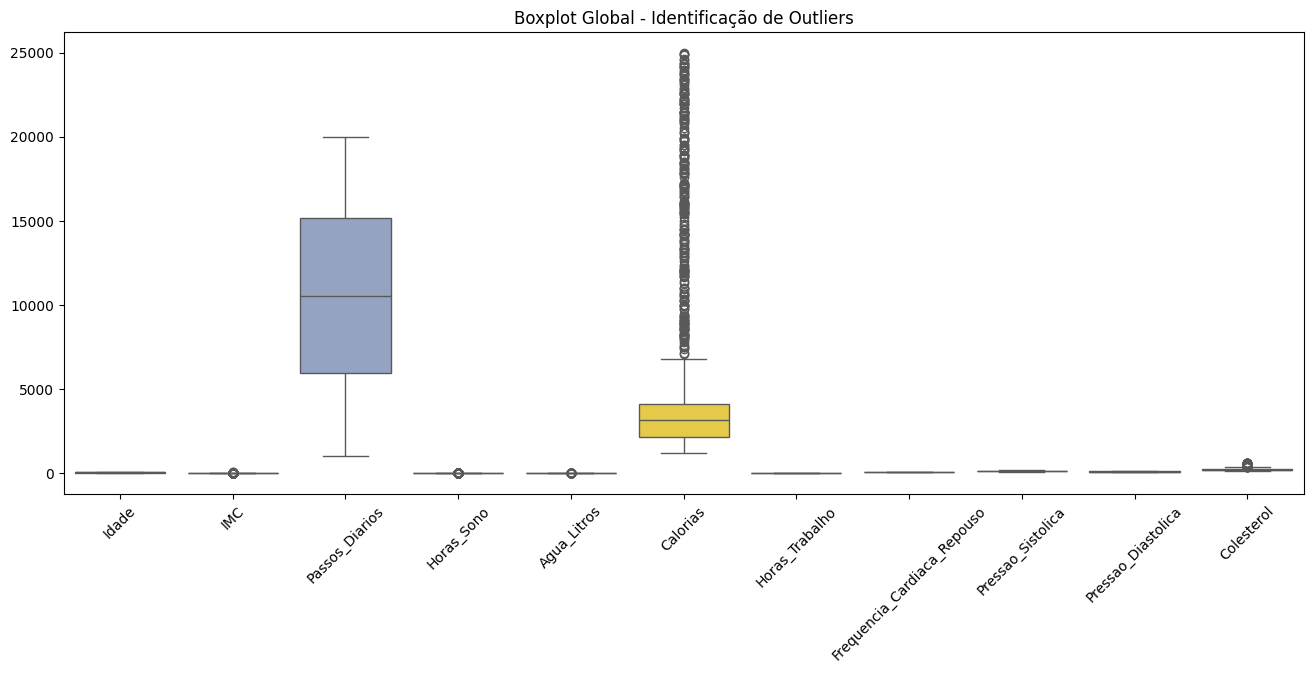

-> IMC: 119 potenciais outliers detectados.
-> Horas_Sono: 116 potenciais outliers detectados.
-> Agua_Litros: 61 potenciais outliers detectados.
-> Calorias: 239 potenciais outliers detectados.
-> Colesterol: 137 potenciais outliers detectados.

=== [4] SELEÇÃO DE FEATURES E CORRELAÇÕES ===


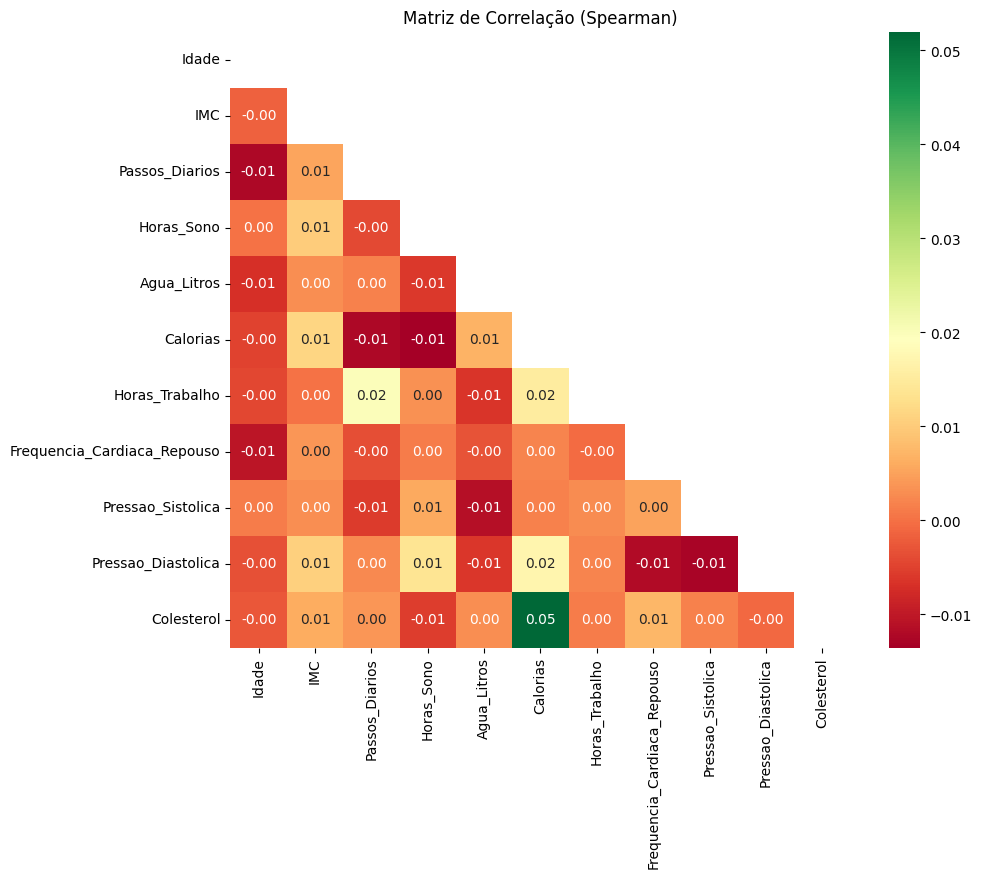

In [234]:
# --- EXECUÇÃO ---
df_final = executar_eda_completa(df_train)

In [237]:
print(239/df_train.shape[0]*100) #1% no máximo é outlier

1.49375


In [238]:
df_final.head()

,Idade,Sexo,IMC,Passos_Diarios,Horas_Sono,Agua_Litros,Calorias,Fumante,Alcool,Horas_Trabalho,Frequencia_Cardiaca_Repouso,Pressao_Sistolica,Pressao_Diastolica,Colesterol,Historico_Familiar,Risco_Doenca
11721,55.0,Feminino,23.8,11375.000000,6.8,1.6,2894.0,Não,Baixo,10,67,93,117,288.0,Não,Baixo
6924,31.0,Feminino,32.5,10538.669593,7.6,3.4,1644.0,Não,Baixo,11,53,169,72,144.0,Sim,Moderado
11252,36.0,Feminino,19.5,18245.000000,4.4,1.7,3984.0,Sim,Baixo,7,66,117,102,178.0,Não,Moderado
16946,30.0,Feminino,22.2,1090.000000,8.5,2.3,3279.0,Sim,Moderado,11,97,131,101,158.0,Sim,Alto
1338,88.0,Feminino,22.3,19744.000000,7.1,1.8,4302.0,Não,Baixo,9,58,141,78,194.0,Não,Baixo


# 3. Preparação dos Dados

Esta é a etapa mais crítica. Evite transformações que removam a interpretabilidade das variáveis.

Tratamento de Dados Ausentes já foi feito.

Foram detectados possíveis outliers.

Será feita visualização dos outliers para possível abordagem de tratamento.

Tratamento de Outliers: Utilize o Z-score ou o método de IQR para tratar valores extremos sem distorcer a realidade clínica.

Codificação: Transforme variáveis categóricas (ex: tipo sanguíneo) usando One-Hot Encoding.

Escalonamento: Aplique StandardScaler ou MinMaxScaler para modelos sensíveis à escala (como SVM ou KNN).

In [239]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 11721 to 8796
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Idade                        16000 non-null  float64
 1   Sexo                         16000 non-null  object 
 2   IMC                          16000 non-null  float64
 3   Passos_Diarios               16000 non-null  float64
 4   Horas_Sono                   16000 non-null  float64
 5   Agua_Litros                  16000 non-null  float64
 6   Calorias                     16000 non-null  float64
 7   Fumante                      16000 non-null  object 
 8   Alcool                       16000 non-null  object 
 9   Horas_Trabalho               16000 non-null  int64  
 10  Frequencia_Cardiaca_Repouso  16000 non-null  int64  
 11  Pressao_Sistolica            16000 non-null  int64  
 12  Pressao_Diastolica           16000 non-null  int64  
 13  Colesterol        

In [240]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.decomposition import PCA
import numpy as np

# Ensure df_final from the previous step is used. Make a copy to avoid modifying the original.
df_processed = df_final.copy()

current_numerical_features = [col for col in df_processed.columns if df_processed[col].dtype in ['int64', 'float64']]

for col in current_numerical_features:
    if df_processed[col].isnull().any():
        df_processed[col] = df_processed[col].fillna(df_processed[col].median())
        print(f"NaNs in '{col}' imputed with median.")

features_for_outlier_scaling = [col for col in current_numerical_features if col not in ['Risco_Doenca']]
features_for_ohe = [col for col in df_processed.columns if df_processed[col].dtype == 'object' and col != 'Risco_Doenca']
target_column = 'Risco_Doenca'

print(f"Features for outlier detection & scaling: {features_for_outlier_scaling}")
print(f"Features for One-Hot Encoding: {features_for_ohe}")
print(f"Target column: {target_column}")

Features for outlier detection & scaling: ['Idade', 'IMC', 'Passos_Diarios', 'Horas_Sono', 'Agua_Litros', 'Calorias', 'Horas_Trabalho', 'Frequencia_Cardiaca_Repouso', 'Pressao_Sistolica', 'Pressao_Diastolica', 'Colesterol']
Features for One-Hot Encoding: ['Sexo', 'Fumante', 'Alcool', 'Historico_Familiar']
Target column: Risco_Doenca


In [247]:
df_view = df_train[features_for_outlier_scaling]
df_view['Risco_Doenca'] = df_train['Risco_Doenca']
#df_view.to_csv('data_view_outliers_saude.tsv', index=False)

/tmp/ipykernel_47638/985262798.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [248]:
df_view

,Idade,IMC,Passos_Diarios,Horas_Sono,Agua_Litros,Calorias,Horas_Trabalho,Frequencia_Cardiaca_Repouso,Pressao_Sistolica,Pressao_Diastolica,Colesterol,Risco_Doenca
11721,55.0,23.8,11375.000000,6.8,1.6,2894.0,10,67,93,117,288.0,Baixo
6924,31.0,32.5,10538.669593,7.6,3.4,1644.0,11,53,169,72,144.0,Moderado
11252,36.0,19.5,18245.000000,4.4,1.7,3984.0,7,66,117,102,178.0,Moderado
16946,30.0,22.2,1090.000000,8.5,2.3,3279.0,11,97,131,101,158.0,Alto
1338,88.0,22.3,19744.000000,7.1,1.8,4302.0,9,58,141,78,194.0,Baixo
...,...,...,...,...,...,...,...,...,...,...,...,...
6669,43.0,23.8,9718.000000,6.8,2.0,3827.0,5,51,118,76,226.0,Baixo
5573,21.0,22.6,9522.000000,7.7,1.8,4660.0,9,90,98,68,212.0,Baixo
10542,20.0,30.3,9221.000000,8.1,2.4,3307.0,12,94,164,60,167.0,Moderado
15408,89.0,23.6,17745.000000,6.9,2.1,19920.0,10,98,129,90,598.0,Moderado


In [242]:
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

In [250]:
pca = PCA(n_components=2)
components = pca.fit_transform(df_view.drop(columns=['Risco_Doenca']))
# Plot
fig = px.scatter(
    components, x=0, y=1,
    color=df_train['Risco_Doenca'].astype(str),
    labels={'0': 'PC 1', '1': 'PC 2'}
)
fig.show()

In [251]:
pca = PCA(n_components=3)
components = pca.fit_transform(df_view.drop(columns=['Risco_Doenca']))
# Plot
fig = px.scatter_3d(
    components, x=0, y=1, z=2,
    color=df_train['Risco_Doenca'].astype(str),
    labels={'0': 'PC 1', '1': 'PC 2', '2': 'PC 3'}
)
fig.show()
#variaveis em escalas distintas

In [252]:
df[features_cat]

,Sexo,Fumante,Alcool,Historico_Familiar
0,Masculino,Não,Moderado,Não
1,Feminino,Não,Moderado,Sim
2,Masculino,Não,Moderado,Sim
3,Feminino,Não,Baixo,Não
4,Masculino,Não,Baixo,Sim
...,...,...,...,...
19995,Masculino,Não,Alto,Sim
19996,Feminino,Não,Baixo,Sim
19997,Masculino,Sim,Moderado,Sim
19998,Feminino,Não,Moderado,Não


In [255]:
for column in df_train[features_cat].columns:
    unique_values = df_train[column].unique()
    print(f"Unique values in column '{column}': {unique_values}")
print(f"Unique values in column '{column}':{df_train['Risco_Doenca'].unique()}")

Unique values in column 'Sexo': ['Feminino' 'Masculino']
Unique values in column 'Fumante': ['Não' 'Sim']
Unique values in column 'Alcool': ['Baixo' 'Moderado' 'Alto']
Unique values in column 'Historico_Familiar': ['Não' 'Sim']
Unique values in column 'Historico_Familiar':['Baixo' 'Moderado' 'Alto' 'Muito Alto']


In [264]:
#encoding não precisa ser ordinal, exceto risco doenca
#valores obedecendo escala 0 a 10 para posterior normalização
#risco doenca obedecendo serie fatorial
transform_sexo = {'Masculino': 0, 'Feminino': 1}
df_train['Sexo'] = df_train['Sexo'].map(transform_sexo)
transform_fumante = {'Não': 0, 'Sim': 1}
df_train['Fumante'] = df_train['Fumante'].map(transform_fumante)
transform_alcool = {'Baixo': 0, 'Moderado': 1, 'Alto':2} #ordem
df_train['Alcool'] = df_train['Alcool'].map(transform_alcool)
transform_historico_familiar = {'Não': 0, 'Sim': 1}
df_train['Historico_Familiar'] = df_train['Historico_Familiar'].map(transform_historico_familiar)
transform_risco_doenca = {'Baixo': 1, 'Moderado': 2, 'Alto': 6, 'Muito Alto': 24} #ordem
df_train['Risco_Doenca'] = df_train['Risco_Doenca'].map(transform_risco_doenca)

In [265]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16000 entries, 11721 to 8796
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Idade                        16000 non-null  float64
 1   Sexo                         16000 non-null  int64  
 2   IMC                          16000 non-null  float64
 3   Passos_Diarios               16000 non-null  float64
 4   Horas_Sono                   16000 non-null  float64
 5   Agua_Litros                  16000 non-null  float64
 6   Calorias                     16000 non-null  float64
 7   Fumante                      16000 non-null  int64  
 8   Alcool                       16000 non-null  int64  
 9   Horas_Trabalho               16000 non-null  int64  
 10  Frequencia_Cardiaca_Repouso  16000 non-null  int64  
 11  Pressao_Sistolica            16000 non-null  int64  
 12  Pressao_Diastolica           16000 non-null  int64  
 13  Colesterol        

In [266]:
print(f"Shape after encoding: {df_train.shape}")

Shape after encoding: (16000, 16)


In [267]:
df_train.columns

Index(['Idade', 'Sexo', 'IMC', 'Passos_Diarios', 'Horas_Sono', 'Agua_Litros',
       'Calorias', 'Fumante', 'Alcool', 'Horas_Trabalho',
       'Frequencia_Cardiaca_Repouso', 'Pressao_Sistolica',
       'Pressao_Diastolica', 'Colesterol', 'Historico_Familiar',
       'Risco_Doenca'],
      dtype='object')

In [261]:
# --- Normalization (StandardScaler) ---
import seaborn as sns
import matplotlib.pyplot as plt

In [268]:
df_train.head()

,Idade,Sexo,IMC,Passos_Diarios,Horas_Sono,Agua_Litros,Calorias,Fumante,Alcool,Horas_Trabalho,Frequencia_Cardiaca_Repouso,Pressao_Sistolica,Pressao_Diastolica,Colesterol,Historico_Familiar,Risco_Doenca
11721,55.0,1,23.8,11375.000000,6.8,1.6,2894.0,0,0,10,67,93,117,288.0,0,1
6924,31.0,1,32.5,10538.669593,7.6,3.4,1644.0,0,0,11,53,169,72,144.0,1,2
11252,36.0,1,19.5,18245.000000,4.4,1.7,3984.0,1,0,7,66,117,102,178.0,0,2
16946,30.0,1,22.2,1090.000000,8.5,2.3,3279.0,1,1,11,97,131,101,158.0,1,6
1338,88.0,1,22.3,19744.000000,7.1,1.8,4302.0,0,0,9,58,141,78,194.0,0,1


In [269]:
cols_parte1 = ['Idade', 'Sexo', 'IMC', 'Passos_Diarios', 'Horas_Sono', 'Agua_Litros','Calorias', 'Fumante','Risco_Doenca']
cols_parte2 = ['Alcool', 'Horas_Trabalho','Frequencia_Cardiaca_Repouso', 'Pressao_Sistolica','Pressao_Diastolica', 'Colesterol', 'Historico_Familiar','Risco_Doenca']

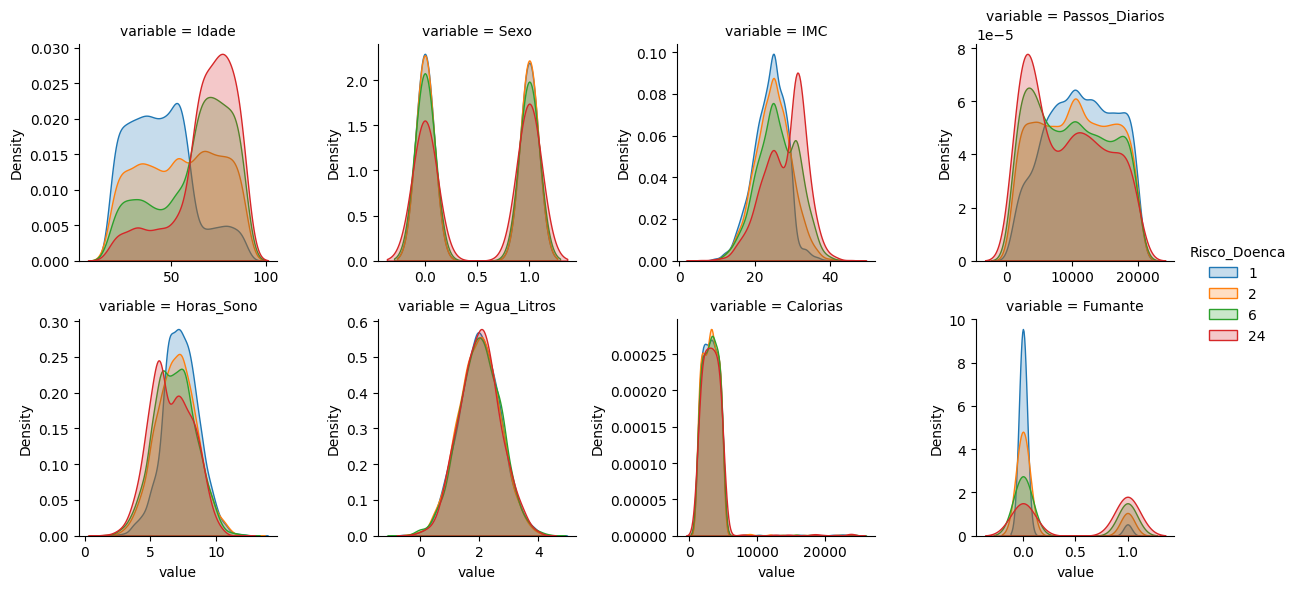

In [270]:
df_long = df_train[cols_parte1].melt(id_vars='Risco_Doenca')
g = sns.FacetGrid(df_long, col="variable", hue="Risco_Doenca", col_wrap=4, sharex=False, sharey=False)
g.map(sns.kdeplot, "value", fill=True)
g.add_legend()
plt.show()

In [192]:
#StandardScaler: Idade, Sexo, IMC, Passos_Diarios, Horas_Sono, Fumante, Agua_Litros, Calorias


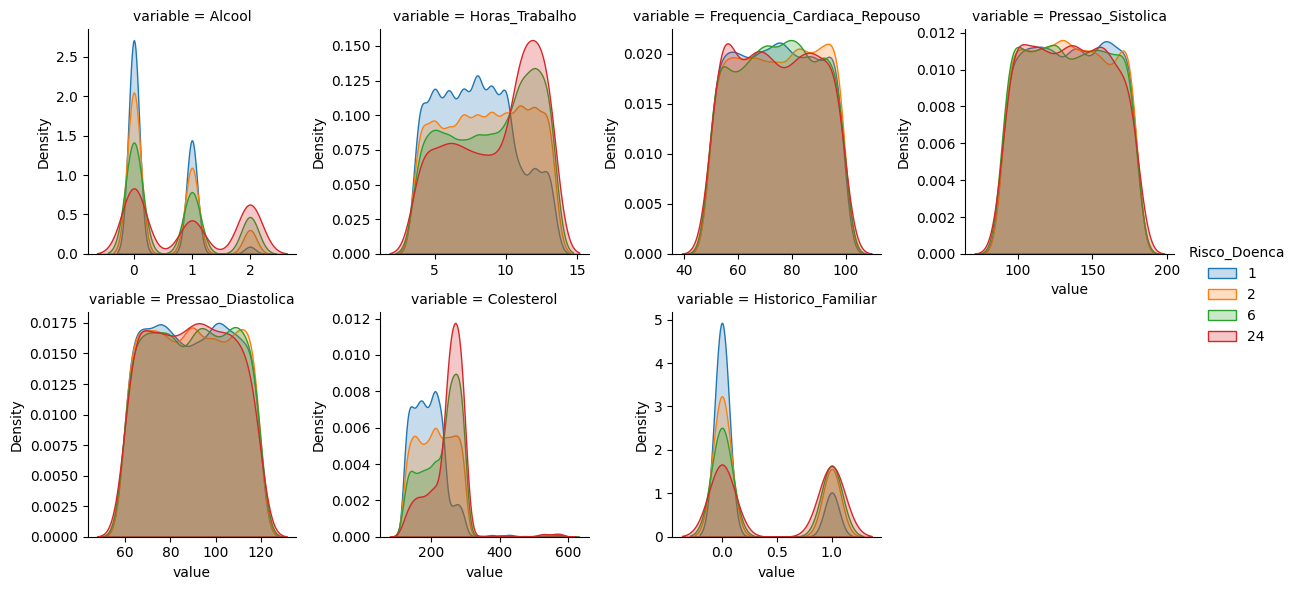

In [271]:
df_long = df_train[cols_parte2].melt(id_vars='Risco_Doenca')
g = sns.FacetGrid(df_long, col="variable", hue="Risco_Doenca", col_wrap=4, sharex=False, sharey=False)
g.map(sns.kdeplot, "value", fill=True)
g.add_legend()
plt.show()

In [ ]:
#sns.pairplot(df, diag_kind='Risco_Doenca', plot_kws={'alpha': 0.5})
#plt.show()

In [272]:
# --- 4. Normalization (StandardScaler) ---
print("\n--- Normalization ---")
scaler = StandardScaler()
df_scaled = df_train.copy()
cols_to_scale_final = [col for col in df_scaled.columns if col != target_column and not (df_scaled[col].dtype == 'uint8' or df_scaled[col].dtype == 'bool')]
if cols_to_scale_final: # Only scale if there are columns to scale
    df_scaled[cols_to_scale_final] = scaler.fit_transform(df_scaled[cols_to_scale_final])
    print(f"Scaled {len(cols_to_scale_final)} numerical features.")
else:
    print("No numerical features found to scale (excluding target and OHE columns).")
print("DataFrame after scaling (first 5 rows of selected scaled features):")
if cols_to_scale_final:
    print(df_scaled[cols_to_scale_final].head())
else:
    print("No features were scaled.")


--- Normalization ---
Scaled 15 numerical features.
DataFrame after scaling (first 5 rows of selected scaled features):
          Idade      Sexo       IMC  Passos_Diarios  Horas_Sono  Agua_Litros  \
11721  0.073646  1.012959 -0.244104        0.154517   -0.133101    -0.562158   
6924  -1.094709  1.012959  1.513720        0.000000    0.398406     1.983823   
11252 -0.851302  1.012959 -1.112913        1.423793   -1.727624    -0.420715   
16946 -1.143391  1.012959 -0.567382       -1.745701    0.996352     0.427946   
1338   1.680135  1.012959 -0.547177        1.700743    0.066214    -0.279271   

       Calorias   Fumante    Alcool  Horas_Trabalho  \
11721 -0.204462 -0.498828 -0.767796        0.522538   
6924  -0.830138 -0.498828 -0.767796        0.872355   
11252  0.341127  2.004700 -0.767796       -0.526911   
16946 -0.011754  2.004700  0.718021        0.872355   
1338   0.500298 -0.498828 -0.767796        0.172722   

       Frequencia_Cardiaca_Repouso  Pressao_Sistolica  Pressao_Dias

In [275]:
df_scaled

,Idade,Sexo,IMC,Passos_Diarios,Horas_Sono,Agua_Litros,Calorias,Fumante,Alcool,Horas_Trabalho,Frequencia_Cardiaca_Repouso,Pressao_Sistolica,Pressao_Diastolica,Colesterol,Historico_Familiar,Risco_Doenca
11721,0.073646,1.012959,-0.244104,0.154517,-0.133101,-0.562158,-0.204462,-0.498828,-0.767796,0.522538,-0.526913,-1.590209,1.584994,1.286278,-0.652998,1
6924,-1.094709,1.012959,1.513720,0.000000,0.398406,1.983823,-0.830138,-0.498828,-0.767796,0.872355,-1.495717,1.324887,-1.002511,-1.173862,1.531398,2
11252,-0.851302,1.012959,-1.112913,1.423793,-1.727624,-0.420715,0.341127,2.004700,-0.767796,-0.526911,-0.596113,-0.669652,0.722492,-0.592996,-0.652998,2
16946,-1.143391,1.012959,-0.567382,-1.745701,0.996352,0.427946,-0.011754,2.004700,0.718021,0.872355,1.549097,-0.132661,0.664992,-0.934682,1.531398,6
1338,1.680135,1.012959,-0.547177,1.700743,0.066214,-0.279271,0.500298,-0.498828,-0.767796,0.172722,-1.149716,0.250904,-0.657510,-0.319647,-0.652998,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6669,-0.510532,-0.987207,-0.244104,-0.151624,-0.133101,0.003616,0.262542,-0.498828,0.718021,-1.226544,-1.634118,-0.631296,-0.772510,0.227051,1.531398,1
5573,-1.581524,1.012959,-0.486562,-0.187836,0.464845,-0.279271,0.679492,-0.498828,-0.767796,0.172722,1.064694,-1.398426,-1.232511,-0.012129,-0.652998,1
10542,-1.630206,1.012959,1.069212,-0.243448,0.730599,0.569389,0.002261,-0.498828,0.718021,1.222171,1.341496,1.133104,-1.692512,-0.780923,-0.652998,2
15408,1.728816,-0.987207,-0.284514,1.331415,-0.066663,0.145059,8.317738,-0.498828,-0.767796,0.522538,1.618297,-0.209374,0.032491,6.582413,-0.652998,2


In [277]:
#visualização
pca = PCA(n_components=2)
components = pca.fit_transform(df_scaled.drop(columns=['Risco_Doenca']))
# Plot
fig = px.scatter(
    components, x=0, y=1,
    color=df_train['Risco_Doenca'].astype(str),
    labels={'0': 'PC 1', '1': 'PC 2'}
)
fig.show()

In [274]:
#visualização
pca = PCA(n_components=3)
components = pca.fit_transform(df_scaled.drop(columns=['Risco_Doenca']))
# Plot
fig = px.scatter_3d(
    components, x=0, y=1, z=2,
    color=df_train['Risco_Doenca'].astype(str),
    labels={'0': 'PC 1', '1': 'PC 2', '2': 'PC 3'}
)
fig.show()

In [ ]:
# --- Outlier Removal (using IQR method) ---
#print("\n--- Outlier Removal ---")
#initial_rows = df_processed.shape[0]
#for col in features_for_outlier_scaling:
#    Q1 = df_processed[col].quantile(0.25)
#    Q3 = df_processed[col].quantile(0.75)
#    IQR = Q3 - Q1
#    lower_bound = Q1 - 1.5 * IQR
#    upper_bound = Q3 + 1.5 * IQR
    # Filter out rows that are not outliers
#    df_processed = df_processed[(df_processed[col] >= lower_bound) & (df_processed[col] <= upper_bound)]
#rows_after_outlier_removal = df_processed.shape[0]
#print(f"Initial number of rows: {initial_rows}")
#print(f"Number of rows after outlier removal: {rows_after_outlier_removal}")
#print(f"Rows removed: {initial_rows - rows_after_outlier_removal}")
#df_processed.reset_index(drop=True, inplace=True)

In [282]:
from sklearn.ensemble import IsolationForest
model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
# O modelo retorna 1 para dados normais e -1 para outliers
df_scaled['anomaly'] = model.fit_predict(df_scaled.drop(columns=['Risco_Doenca']))
# Filtrando os dados (Removendo os outliers)
df_clean = df_scaled[df_scaled['anomaly'] == 1].drop(columns=['anomaly'])
df_outliers = df_scaled[df_scaled['anomaly'] == -1]
print(f"Tamanho original: {len(df_scaled)}")
print(f"Dados após remoção: {len(df_clean)}")

Tamanho original: 16000
Dados após remoção: 15200


In [283]:
print(15200/16000)

0.95


In [284]:
df_clean

,Idade,Sexo,IMC,Passos_Diarios,Horas_Sono,Agua_Litros,Calorias,Fumante,Alcool,Horas_Trabalho,Frequencia_Cardiaca_Repouso,Pressao_Sistolica,Pressao_Diastolica,Colesterol,Historico_Familiar,Risco_Doenca
11721,0.073646,1.012959,-0.244104,0.154517,-0.133101,-0.562158,-0.204462,-0.498828,-0.767796,0.522538,-0.526913,-1.590209,1.584994,1.286278,-0.652998,1
6924,-1.094709,1.012959,1.513720,0.000000,0.398406,1.983823,-0.830138,-0.498828,-0.767796,0.872355,-1.495717,1.324887,-1.002511,-1.173862,1.531398,2
11252,-0.851302,1.012959,-1.112913,1.423793,-1.727624,-0.420715,0.341127,2.004700,-0.767796,-0.526911,-0.596113,-0.669652,0.722492,-0.592996,-0.652998,2
16946,-1.143391,1.012959,-0.567382,-1.745701,0.996352,0.427946,-0.011754,2.004700,0.718021,0.872355,1.549097,-0.132661,0.664992,-0.934682,1.531398,6
1338,1.680135,1.012959,-0.547177,1.700743,0.066214,-0.279271,0.500298,-0.498828,-0.767796,0.172722,-1.149716,0.250904,-0.657510,-0.319647,-0.652998,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11971,0.998594,-0.987207,-1.537216,-0.081232,-0.797485,0.286502,-0.532817,-0.498828,-0.767796,0.172722,1.272295,0.749539,-0.025009,-0.029214,1.531398,2
1328,1.436728,1.012959,1.938022,-0.232732,-1.461870,-0.420715,0.510810,-0.498828,0.718021,1.571987,-0.596113,-0.209374,-1.520012,-1.122609,1.531398,24
6669,-0.510532,-0.987207,-0.244104,-0.151624,-0.133101,0.003616,0.262542,-0.498828,0.718021,-1.226544,-1.634118,-0.631296,-0.772510,0.227051,1.531398,1
5573,-1.581524,1.012959,-0.486562,-0.187836,0.464845,-0.279271,0.679492,-0.498828,-0.767796,0.172722,1.064694,-1.398426,-1.232511,-0.012129,-0.652998,1


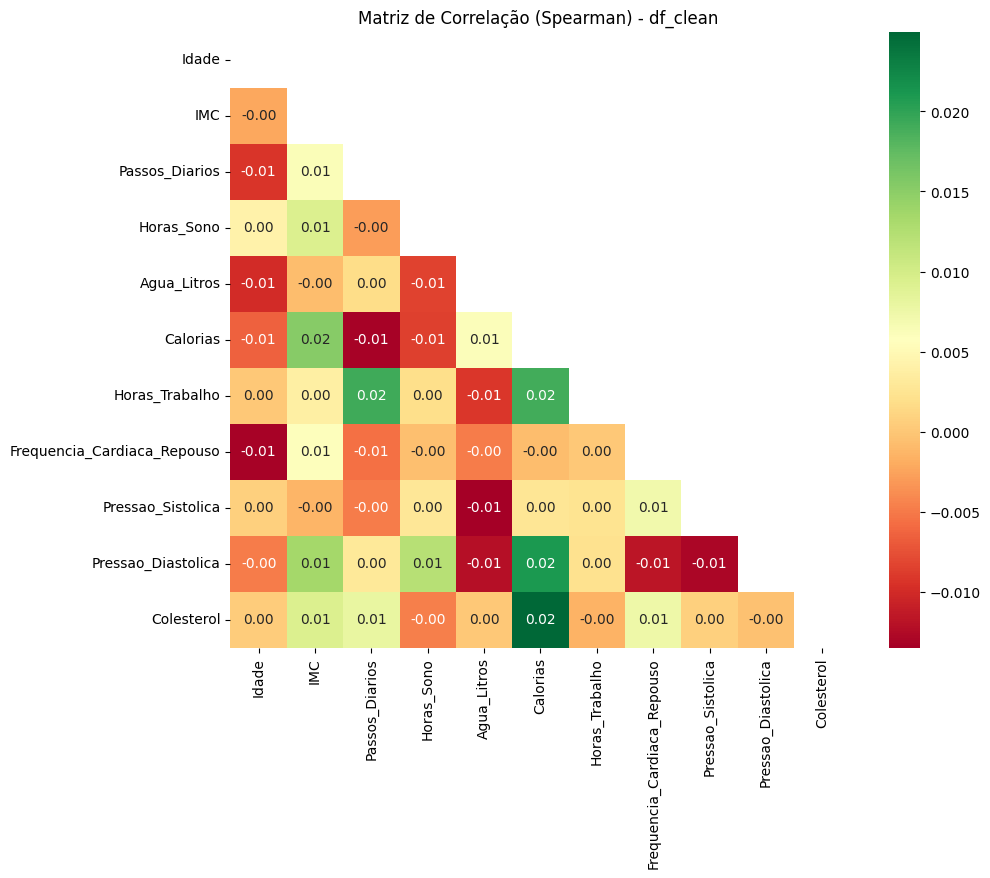

In [287]:
plt.figure(figsize=(10, 8))
corr = df_clean[features_num].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Matriz de Correlação (Spearman) - df_clean ")
plt.show()

In [292]:
# --- 5. PCA (Principal Component Analysis) ---
print("\n--- Principal Component Analysis (PCA) ---")
# Separate features (X) and target (y)
X = df_clean.drop(columns=[target_column])
y = df_clean[target_column]

if X.shape[1] > 1: # PCA requires more than 1 feature
    pca = PCA(n_components=0.60) # Retain components that explain % of the variance
    X_pca = pca.fit_transform(X)

    df_pca = pd.DataFrame(data=X_pca,
                          columns=[f'PC_{i+1}' for i in range(X_pca.shape[1])])
    df_pca[target_column] = y.reset_index(drop=True) # Add target back

    print(f"Original number of features: {X.shape[1]}")
    print(f"Number of components after PCA (explaining % variance): {X_pca.shape[1]}")
    print("DataFrame after PCA (first 5 rows):")
    print(df_pca.head())
    print("\nData preparation complete. `df_pca` contains the transformed and scaled data with reduced dimensionality.")
else:
    df_pca = df_scaled.copy() # If PCA not applicable, keep the scaled dataframe
    print("PCA not applied as there are too few features for dimensionality reduction.")
    print("`df_scaled` will be used as the final prepared dataframe.")


--- Principal Component Analysis (PCA) ---
Original number of features: 15
Number of components after PCA (explaining % variance): 9
DataFrame after PCA (first 5 rows):
       PC_1      PC_2      PC_3      PC_4      PC_5      PC_6      PC_7  \
0  1.354049  0.781934  1.054703 -0.480721 -1.097872  0.685490 -0.544911   
1 -0.365433 -0.031205  0.488745 -0.453583  0.754289 -0.023679  1.766909   
2  1.578112  0.712138  0.039532 -1.199741  1.016590 -0.053139 -0.570135   
3 -0.997166  0.472020 -0.199997  0.534853 -0.309577  2.273346  0.259713   
4  2.096928 -1.198277  0.580084 -0.003860  0.012453 -0.913227  1.047505   

       PC_8      PC_9  Risco_Doenca  
0  0.001255  0.351348             1  
1 -1.486837 -2.463592             2  
2 -1.406084  0.270949             2  
3 -0.968088  0.443738             6  
4 -0.410822  0.293224             1  

Data preparation complete. `df_pca` contains the transformed and scaled data with reduced dimensionality.


In [298]:
#balanceamento das classes
df_clean['Risco_Doenca'].value_counts()/df_clean.shape[0]*100

,count
Risco_Doenca,
1,36.861842
2,36.453947
6,20.578947
24,6.105263


Transformações : s**plit 80/20, remoção ID, encoding, preenchimento ausentes com mean,** verificação da existência de outliers numericamente, verificação via pca, **padronização**, verificação via pca, **remoção dos outliers via Isolation Forest, PCA**.